The goal here is to do a *single* forward model that could be compared to a single MSA exposure.  The intent here is to work out all the steps, get rough timing, and use that to determine which need further optimization.  All relevant notebooks start with `single_forward_model`.

This comes after the PSF grid was generated in [single_forward_model3_psfgrid.ipynb](single_forward_model3_psfgrid.ipynb)

In [135]:
import time
import pickle
from pathlib import Path

import numpy as np

from matplotlib import pyplot as plt

from astropy import visualization as viz
viz.quantity_support()
from jwst import datamodels

from astropy import units as u
from astropy.coordinates import SkyCoord, SpectralCoord

from photutils import psf

from tqdm.auto import tqdm


# Load Data and Information

In [2]:
n6791fits = list(Path('../ngc6791_cals').glob('*.fits'))

dm0 = datamodels.open(n6791fits[0])

slit = dm0.slits[49]
scoord = SkyCoord(slit.source_ra, slit.source_dec, unit='deg')
swcs = slit.meta.wcs

assert slit.source_name == '2609_21'

In [3]:
apogee_id = '2M19210086+3745339'
apogee_vhelio_avg = -45.42058
apogee_vunc = 0.1100559
apogee_teff = 4416.742
apogee_logg = 2.269546
apogee_m_h = 0.34755

apogee_feh = np.log10(apogee_m_h)

In [208]:
with open('single_forward_model_model_spec.pkl', 'rb') as f:
    data = pickle.load(f)

model_wave = data['wave']
model_freq = model_wave.to(u.Hz, equivalencies=u.spectral())
model_flux = data['model']
model_path = data['phoenix_path']

# note that the normalization is at the "surface" of the star, so its crazy high - renormalize as needed
model_flux_fnu = model_flux.to(u.MJy, equivalencies=u.spectral_density(model_wave)) 

del data

In [ ]:
with open('single_forward_model_psf_grid_os4.pkl', 'rb') as f:
    data = pickle.load(f)

psf_interpolator = data['psf_grid']
psf_wl_grid = data['psf_wl_grid']

psf_source_offset_x_px = data['psf_source_offset_x_px']
psf_source_offset_y_px = data['psf_source_offset_y_px']
psf_source_offset_x_asec = data['psf_source_offset_x_asec']
psf_source_offset_y_asec = data['psf_source_offset_y_asec']

del data

# Make an artificial spectrum

This is the core computational step - producing a 2d spectrum from the 1d spectrum and PSF

Some unanswered questions:

1. How literally do we take the PSF flux normalization?  Is the wavelength dependence relizble or do they need to be re-normalized and filter-convolved or something?
2. Is there any other wavelength-dependence that is not in the data calibration?
3. Is the "drizzle" sampling sufficient to capture the sub-pixel spacing?


## Pre-steps

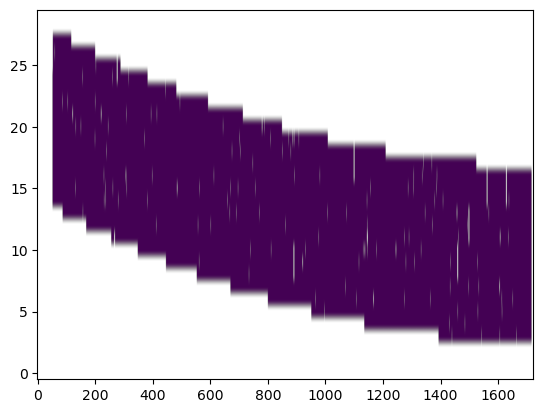

In [6]:
model_slit_templ = slit.data.copy().astype(float)  # the copy isn't really necessary but it provides emotional safety ;)
model_slit_templ *= 0  # makes the data all zero except the nans
plt.imshow(model_slit_templ, aspect='auto', origin='lower')

In [7]:
st = time.time()
center_x, center_y = swcs.world_to_pixel(scoord, SpectralCoord(model_wave))
et = time.time()
et-st

0.07576465606689453

100 ms is very slow for a per-iteration step, will need to accelerate this

## Model construction tests

First make sure the PSF makes sense

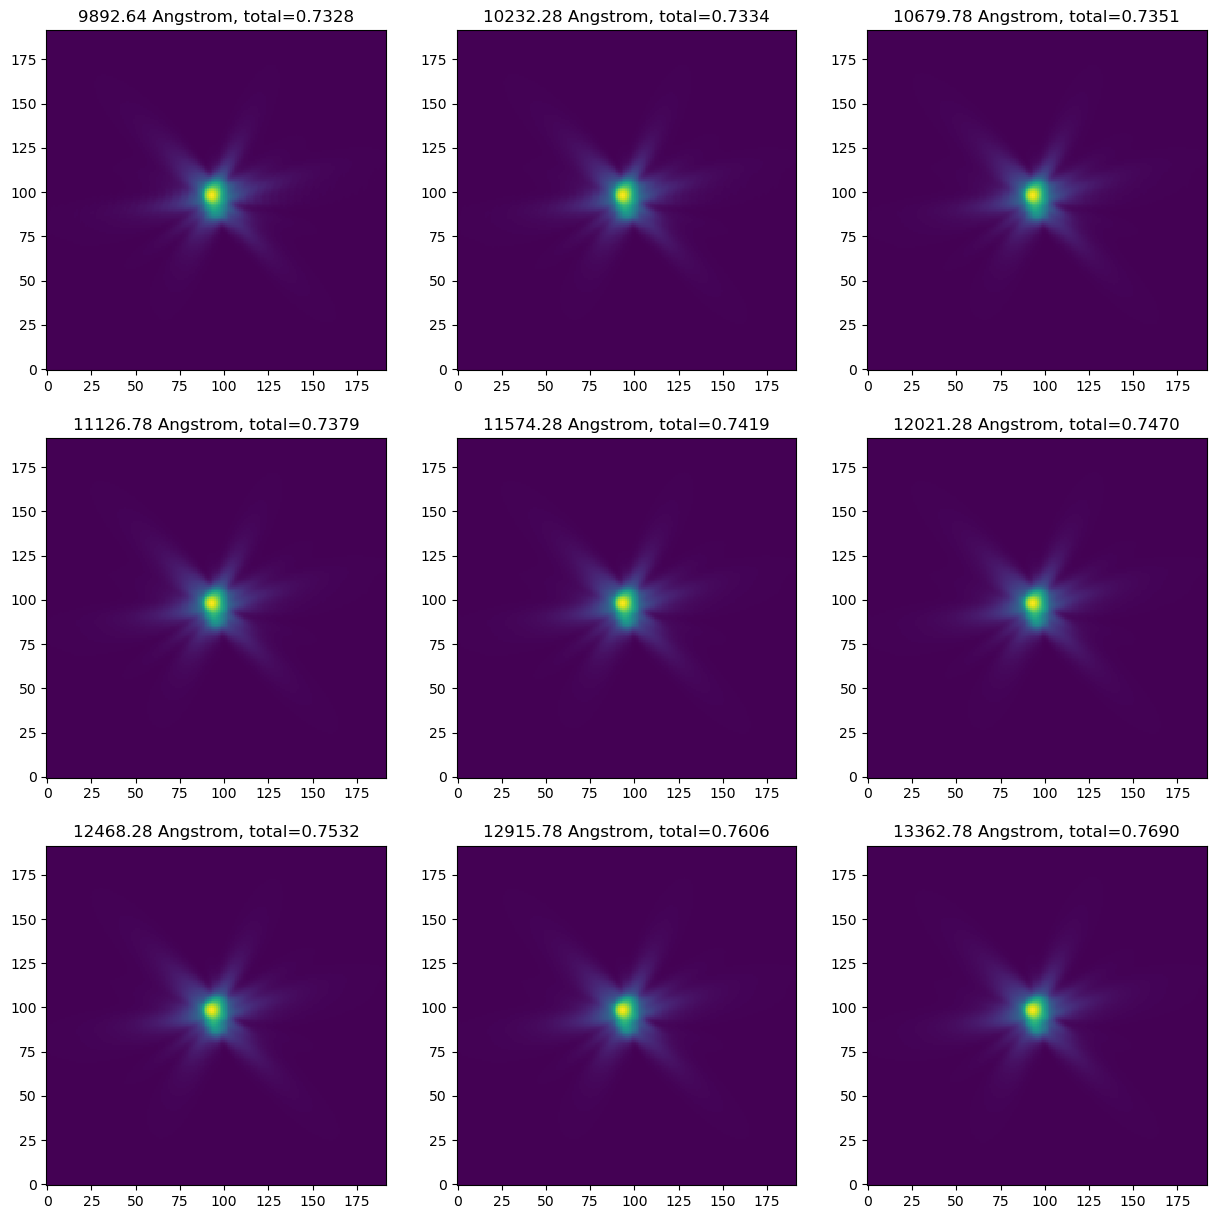

In [38]:
wls = model_wave[np.linspace(0, model_wave.shape[-1] - 1, 9+2)[1:-1].astype(int)]
sqp = int(np.ceil(len(wls)**0.5))
fig, axs = plt.subplots(sqp, sqp, figsize=(5*sqp, 5*sqp))

for wl, ax in zip(wls, axs.ravel()):
    psfi = psf_interpolator(wl.to(psf_wl_grid.unit))
    viz.imshow_norm(psfi, origin='lower', interpolation='nearest', ax=ax,
                    stretch=viz.LogStretch(1e5), interval=viz.MinMaxInterval())
    ax.set_title(f'{wl:.2f}, total={psfi.sum():.4f}')

Now make a fake spectrum from the psf with a specified dispersion

Elapsed time: 0.0262 seconds


(<Quantity [11074.28, 12054.28] Angstrom>,
 <Quantity [ 9669.14, 13810.28] Angstrom>)

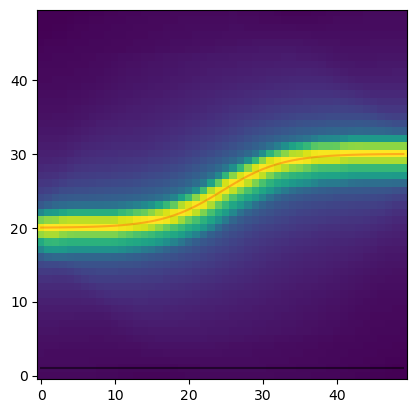

In [175]:
dispersion = 20*u.angstrom/u.pixel

fake_image = np.zeros((50, 50), dtype=float)
fake_wl = (np.arange(50)-25)*u.pixel * dispersion + model_wave[len(model_wave) // 2]

yprofile = 5*np.tanh(np.linspace(-1, 1, fake_image.shape[1])*3) + fake_image.shape[0]/2

fakespec = np.ones(fake_image.shape[0])

st = time.time()
for i, wl in enumerate(fake_wl):
    psfi = psf_interpolator(wl.to(psf_wl_grid.unit))
    xs = np.round(psf_source_offset_x_px + i).astype(int)
    ys = np.round(psf_source_offset_y_px + yprofile[i]).astype(int)
    msk = (xs >= 0) & (xs < fake_image.shape[1]) & (ys >= 0) & (ys < fake_image.shape[0])
    np.add.at(fake_image, (xs[msk], ys[msk]), fakespec[i]*psfi[msk])
et = time.time()
print(f'Elapsed time: {et-st:.3} seconds')

viz.imshow_norm(fake_image.T, origin='lower', interpolation='nearest',
                stretch=viz.LogStretch(1e5), interval=viz.MinMaxInterval())
plt.plot(yprofile, alpha=.25, c='r')
plt.plot(fakespec/np.mean(fakespec), alpha=.5, c='k')
fake_wl[np.array((0,-1))], model_wave[np.array((0,-1))]

Elapsed time: 0.0246 seconds


(<Quantity [11074.28, 12054.28] Angstrom>,
 <Quantity [ 9669.14, 13810.28] Angstrom>)

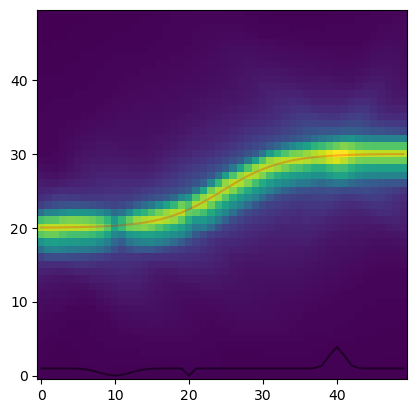

In [176]:
dispersion = 20*u.angstrom/u.pixel

fake_image = np.zeros((50, 50), dtype=float)
fake_wl = (np.arange(50)-25)*u.pixel * dispersion + model_wave[len(model_wave) // 2]

yprofile = 5*np.tanh(np.linspace(-1, 1, fake_image.shape[1])*3) + fake_image.shape[0]/2

xpx = np.arange(fake_image.shape[0])
fakespec = np.ones(fake_image.shape[0]) - np.exp(-0.5*((xpx-10)/2)**2) - np.exp(-0.5*((xpx-20)/.3)**2) + 3*np.exp(-0.5*((xpx-40)/1)**2)

st = time.time()
for i, wl in enumerate(fake_wl):
    psfi = psf_interpolator(wl.to(psf_wl_grid.unit))
    xs = np.round(psf_source_offset_x_px + i).astype(int)
    ys = np.round(psf_source_offset_y_px + yprofile[i]).astype(int)
    msk = (xs >= 0) & (xs < fake_image.shape[1]) & (ys >= 0) & (ys < fake_image.shape[0])
    np.add.at(fake_image, (xs[msk], ys[msk]), fakespec[i]*psfi[msk])
et = time.time()
print(f'Elapsed time: {et-st:.3} seconds')

viz.imshow_norm(fake_image.T, origin='lower', interpolation='nearest',
                stretch=viz.LogStretch(1e5), interval=viz.MinMaxInterval())
plt.plot(yprofile, alpha=.25, c='r')
plt.plot(fakespec/np.mean(fakespec), alpha=.5, c='k')
fake_wl[np.array((0,-1))], model_wave[np.array((0,-1))]

Elapsed time: 0.0271 seconds


(<Quantity [ 9324.28, 13734.28] Angstrom>,
 <Quantity [ 9669.14, 13810.28] Angstrom>)

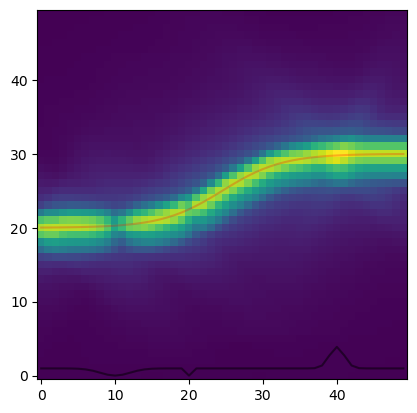

In [177]:
dispersion = 90*u.angstrom/u.pixel

fake_image = np.zeros((50, 50), dtype=float)
fake_wl = (np.arange(50)-25)*u.pixel * dispersion + model_wave[len(model_wave) // 2]

yprofile = 5*np.tanh(np.linspace(-1, 1, fake_image.shape[1])*3) + fake_image.shape[0]/2

xpx = np.arange(fake_image.shape[0])
fakespec = np.ones(fake_image.shape[0]) - np.exp(-0.5*((xpx-10)/2)**2) - np.exp(-0.5*((xpx-20)/.3)**2) + 3*np.exp(-0.5*((xpx-40)/1)**2)

st = time.time()
for i, wl in enumerate(fake_wl):
    psfi = psf_interpolator(wl.to(psf_wl_grid.unit))
    xs = np.round(psf_source_offset_x_px + i).astype(int)
    ys = np.round(psf_source_offset_y_px + yprofile[i]).astype(int)
    msk = (xs >= 0) & (xs < fake_image.shape[1]) & (ys >= 0) & (ys < fake_image.shape[0])
    np.add.at(fake_image, (xs[msk], ys[msk]), fakespec[i]*psfi[msk])
et = time.time()
print(f'Elapsed time: {et-st:.3} seconds')

viz.imshow_norm(fake_image.T, origin='lower', interpolation='nearest',
                stretch=viz.LogStretch(1e5), interval=viz.MinMaxInterval())
plt.plot(yprofile, alpha=.25, c='r')
plt.plot(fakespec/np.mean(fakespec), alpha=.5, c='k')
fake_wl[np.array((0,-1))], model_wave[np.array((0,-1))]

Elapsed time: 0.0307 seconds


(<Quantity [11549.28, 11598.28] Angstrom>,
 <Quantity [ 9669.14, 13810.28] Angstrom>)

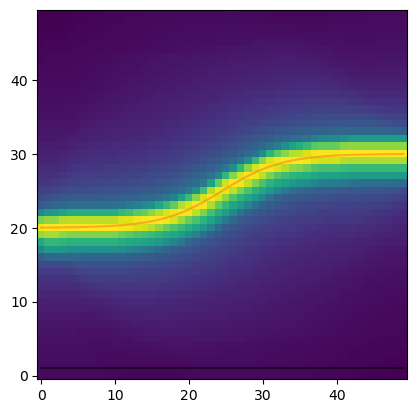

In [178]:
dispersion = 1*u.angstrom/u.pixel

fake_image = np.zeros((50, 50), dtype=float)
fake_wl = (np.arange(50)-25)*u.pixel * dispersion + model_wave[len(model_wave) // 2]

yprofile = 5*np.tanh(np.linspace(-1, 1, fake_image.shape[1])*3) + fake_image.shape[0]/2

fakespec = np.ones(fake_image.shape[0])

st = time.time()
for i, wl in enumerate(fake_wl):
    psfi = psf_interpolator(wl.to(psf_wl_grid.unit))
    xs = np.round(psf_source_offset_x_px + i).astype(int)
    ys = np.round(psf_source_offset_y_px + yprofile[i]).astype(int)
    msk = (xs >= 0) & (xs < fake_image.shape[1]) & (ys >= 0) & (ys < fake_image.shape[0])
    np.add.at(fake_image, (xs[msk], ys[msk]), fakespec[i]*psfi[msk])
et = time.time()
print(f'Elapsed time: {et-st:.3} seconds')

viz.imshow_norm(fake_image.T, origin='lower', interpolation='nearest',
                stretch=viz.LogStretch(1e5), interval=viz.MinMaxInterval())
plt.plot(yprofile, alpha=.25, c='r')
plt.plot(fakespec/np.mean(fakespec), alpha=.5, c='k')
fake_wl[np.array((0,-1))], model_wave[np.array((0,-1))]

Try an alternative approach using photutils' PSF machinery

Elapsed time: 0.0225 seconds


(<Quantity [11074.28, 12054.28] Angstrom>,
 <Quantity [ 9669.14, 13810.28] Angstrom>)

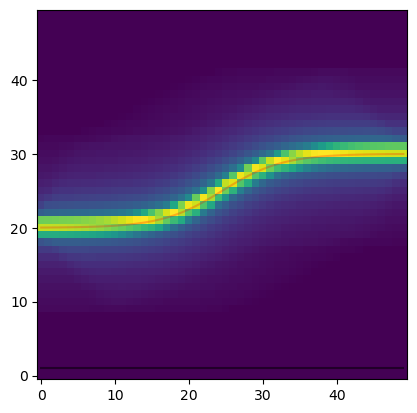

In [198]:
dispersion = 20*u.angstrom/u.pixel

fake_image = np.zeros((50, 50), dtype=float)
fake_wl = (np.arange(50)-25)*u.pixel * dispersion + model_wave[len(model_wave) // 2]

yprofile = 5*np.tanh(np.linspace(-1, 1, fake_image.shape[1])*3) + fake_image.shape[0]/2

fakespec = np.ones(fake_image.shape[0])

# this does not do the interpolation but is just a test of this approach
psfi = psf_interpolator(psf_wl_grid[psf_wl_grid.shape[0]//2])
psfo = psf.ImagePSF(psfi, oversampling=8, )

st = time.time()
for i, wl in enumerate(fake_wl):
    psfo.x_0 = i
    psfo.y_0 = yprofile[i]
    psfo.render(fake_image.T)

et = time.time()
print(f'Elapsed time: {et-st:.3} seconds')

viz.imshow_norm(fake_image.T, origin='lower', interpolation='nearest',
                stretch=viz.LogStretch(1e5), interval=viz.MinMaxInterval())
plt.plot(yprofile, alpha=.25, c='r')
plt.plot(fakespec/np.mean(fakespec), alpha=.5, c='k')
fake_wl[np.array((0,-1))], model_wave[np.array((0,-1))]

Not really a lot faster, so stick with the simpler way for testing.

  0%|          | 0/8945 [00:00<?, ?it/s]

/tmp/ipykernel_26933/2357776193.py:17: RuntimeWarning: invalid value encountered in cast
  xs = np.round(psf_source_offset_x_px + xc).astype(int)


(0.00023174285888671875, 0.10999608039855957, 3.0941591262817383)

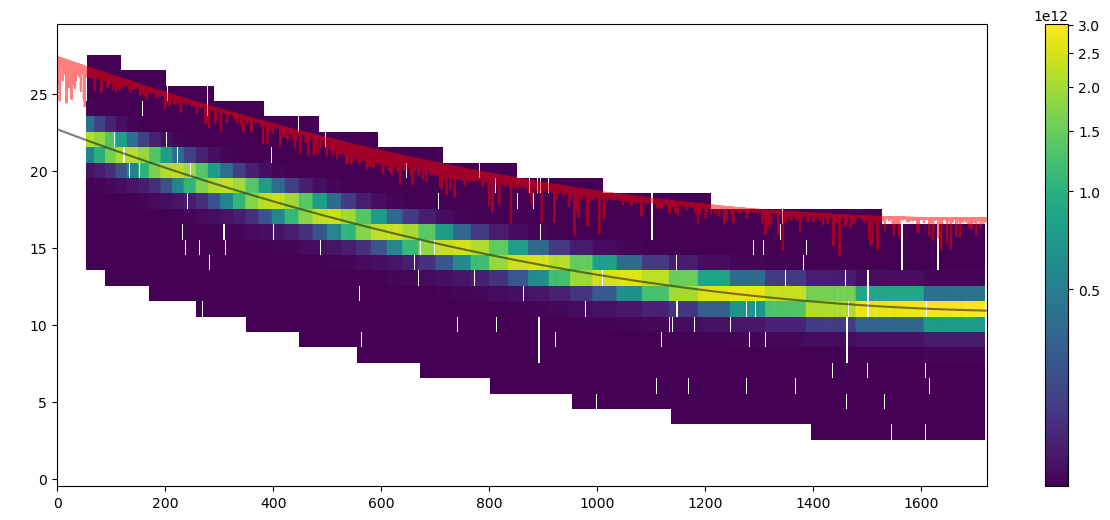

In [353]:
t1 = time.time()

model_slit = model_slit_templ.copy()

t2 = time.time()

dwl = 0.1*u.angstrom
x1, y1 = swcs.world_to_pixel(scoord, SpectralCoord(model_wave))
x2, y2 = swcs.world_to_pixel(scoord, SpectralCoord(model_wave+dwl))
det_disp = np.hypot(x2-x1, y2-y1)*u.pixel/dwl

model_flux_fnu_dispcorr = model_flux_fnu * np.gradient(model_wave)/u.pixel * det_disp

t3 = time.time()
for fnuish, wl, xc, yc in tqdm(list(zip(model_flux_fnu_dispcorr, model_wave, center_x, center_y))):
    psfi = psf_interpolator(wl.to(psf_wl_grid.unit)) * fnuish
    xs = np.round(psf_source_offset_x_px + xc).astype(int)
    ys = np.round(psf_source_offset_y_px + yc).astype(int)

    msk = (xs >= 0) & (xs < model_slit.shape[1]) & (ys >= 0) & (ys < model_slit.shape[0])

    np.add.at(model_slit, (ys[msk], xs[msk]), psfi.value[msk])
t4 = time.time()

plt.figure(figsize=(15, 6))
sc = viz.imshow_norm(model_slit,
                stretch=viz.AsinhStretch(), interval=viz.AsymmetricPercentileInterval(50, 99.99), 
                aspect='auto', origin='lower', interpolation='nearest')[0]
plt.plot(center_x, center_y, color='k', alpha=0.5)
plt.plot(center_x, center_y + 6*model_flux_fnu/np.max(model_flux_fnu), color='r', alpha=0.5)
plt.colorbar(sc)

t2 - t1, t3 - t2, t4 - t3
    

Compare to real data

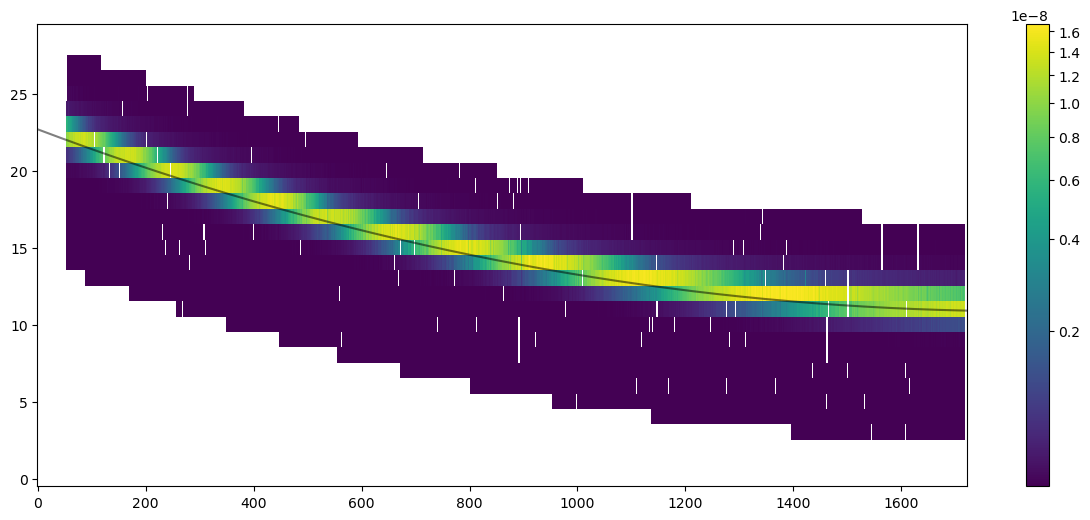

In [349]:
plt.figure(figsize=(15, 6))
sc = viz.imshow_norm(slit.data,
                stretch=viz.AsinhStretch(), interval=viz.AsymmetricPercentileInterval(50, 99.99), 
                aspect='auto', origin='lower', interpolation='nearest')[0]
plt.plot(center_x, center_y, color='k', alpha=0.5)
plt.colorbar(sc)

What's up with the banding?

  0%|          | 0/8945 [00:00<?, ?it/s]

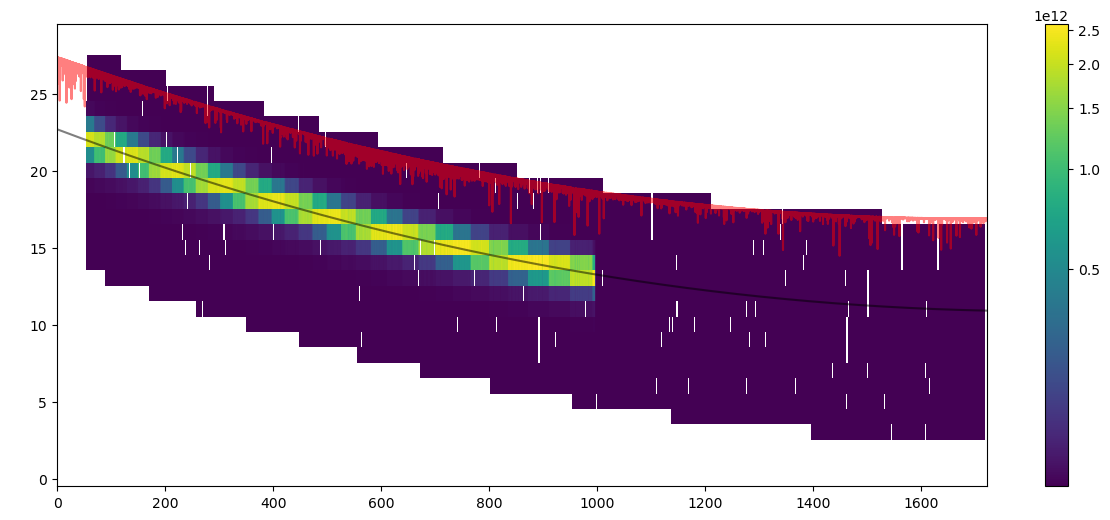

In [363]:
t1 = time.time()

model_slit = model_slit_templ.copy()

t2 = time.time()

dwl = 0.1*u.angstrom
x1, y1 = swcs.world_to_pixel(scoord, SpectralCoord(model_wave))
x2, y2 = swcs.world_to_pixel(scoord, SpectralCoord(model_wave+dwl))
det_disp = np.hypot(x2-x1, y2-y1)*u.pixel/dwl

model_flux_fnu_dispcorr = model_flux_fnu * np.gradient(model_wave)/u.pixel * det_disp

t3 = time.time()
for fnuish, wl, xc, yc in tqdm(list(zip(model_flux_fnu_dispcorr, model_wave, center_x, center_y))):
    if xc > 995:
        break
    psfi = psf_interpolator(wl.to(psf_wl_grid.unit)) * fnuish
    xs = np.round(psf_source_offset_x_px + xc).astype(int)
    ys = np.round(psf_source_offset_y_px + yc).astype(int)

    msk = (xs >= 0) & (xs < model_slit.shape[1]) & (ys >= 0) & (ys < model_slit.shape[0])

    np.add.at(model_slit, (ys[msk], xs[msk]), psfi.value[msk])



plt.figure(figsize=(15, 6))
sc = viz.imshow_norm(model_slit,
                stretch=viz.AsinhStretch(), interval=viz.AsymmetricPercentileInterval(50, 99.99), 
                aspect='auto', origin='lower', interpolation='nearest')[0]
plt.plot(center_x, center_y, color='k', alpha=0.5)
plt.plot(center_x, center_y + 6*model_flux_fnu/np.max(model_flux_fnu), color='r', alpha=0.5)
plt.colorbar(sc)
t4 = time.time()


(5.0, 20.0)

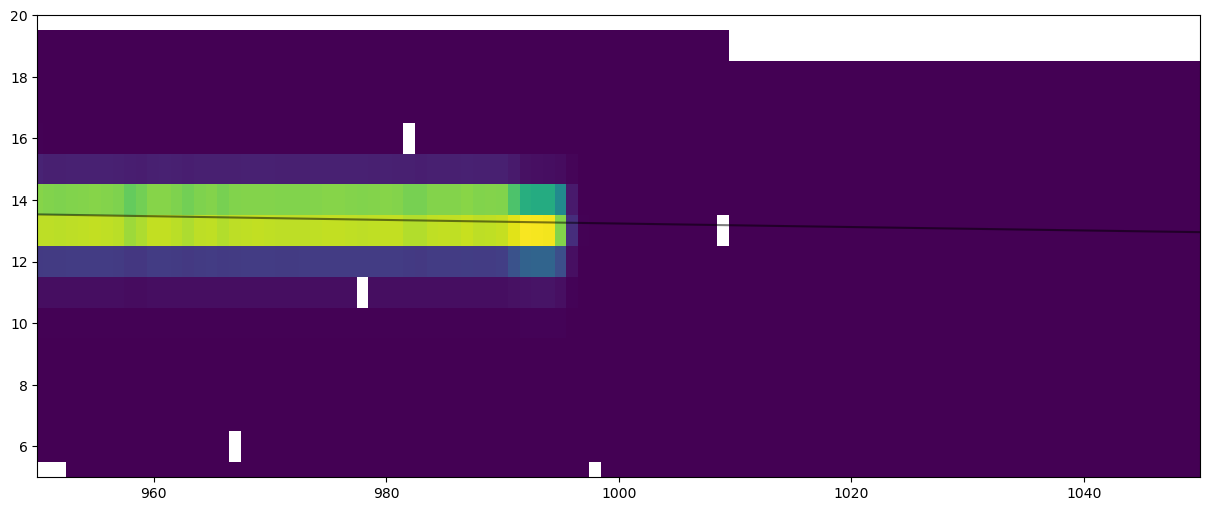

In [364]:
plt.figure(figsize=(15, 6))
sc = viz.imshow_norm(model_slit,
                stretch=viz.AsinhStretch(), interval=viz.AsymmetricPercentileInterval(50, 99.99), 
                aspect='auto', origin='lower', interpolation='nearest')[0]
plt.plot(center_x, center_y, color='k', alpha=0.5)

plt.xlim(950, 1050)
plt.ylim(5, 20)

In [402]:

model_slit = model_slit_templ.copy()


dwl = 0.1*u.angstrom
x1, y1 = swcs.world_to_pixel(scoord, SpectralCoord(model_wave))
x2, y2 = swcs.world_to_pixel(scoord, SpectralCoord(model_wave+dwl))
det_disp = np.hypot(x2-x1, y2-y1)*u.pixel/dwl

model_flux_fnu_dispcorr = model_flux_fnu * np.gradient(model_wave)/u.pixel * det_disp

cuts = np.linspace(987, 997, 6)
models = []
psfsss =[]
for cutx in tqdm(cuts):
    model_slit = model_slit_templ.copy()
    for fnuish, wl, xc, yc in list(zip(model_flux_fnu_dispcorr, model_wave, center_x, center_y)):
        if xc > cutx:
            break
        psfi = psf_interpolator(wl.to(psf_wl_grid.unit)) * fnuish
        xf = psf_source_offset_x_px + xc
        yf = psf_source_offset_y_px + yc
        xs = np.round(xf).astype(int)
        ys = np.round(yf).astype(int)

        msk = (xs >= 0) & (xs < model_slit.shape[1]) & (ys >= 0) & (ys < model_slit.shape[0])

        np.add.at(model_slit, (ys[msk], xs[msk]), psfi.value[msk])
    models.append(model_slit)
    psfsss.append((psfi, xf, yf))


  0%|          | 0/6 [00:00<?, ?it/s]

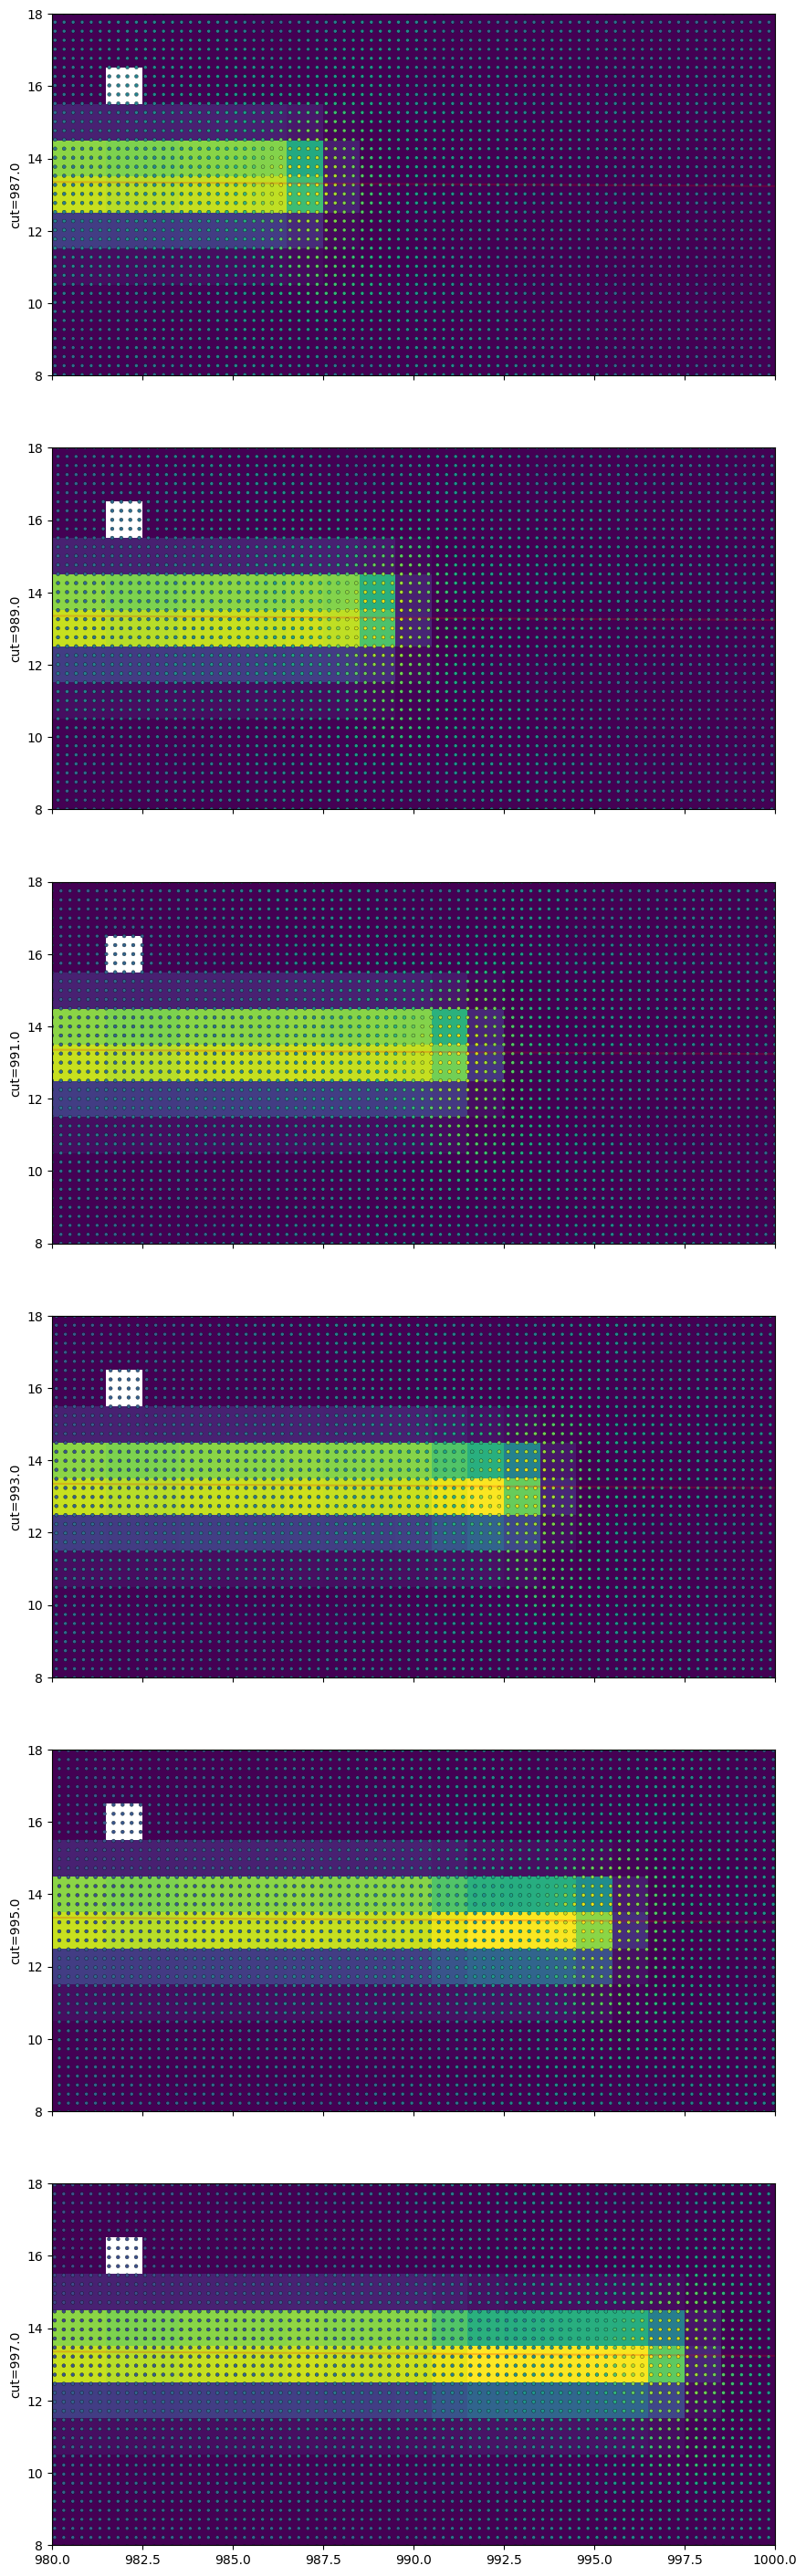

In [403]:
fig, axs = plt.subplots(len(models), 1, figsize=(15, len(models)*6), sharex=True)
for m, ax, c, (psfi, xf, yf) in zip(models, axs, cuts, psfsss):
    viz.imshow_norm(m, ax=ax, origin='lower', interpolation='nearest',
                    stretch=viz.AsinhStretch(), interval=viz.AsymmetricPercentileInterval(1, 99.9))
    ax.set_ylabel(f'cut={c}')

    ax.scatter(xf, yf, c=np.log10(psfi.value), s=8, lw=.2, edgecolor='k')

    ax.set_xlim(980, 1000)
    ax.set_ylim(8, 18)
    ax.plot(center_x, center_y, color='r', alpha=0.2)

Aha!  The banding is from the grid of the PSF crossing into the pixel in an almost-but-not-quite-aligned way.

NOTE: This version of the notebook was made with oversampling=4 and default fov